# IMAGE REGISTRATION
The data I will use in this part of the project are T1_BRAIN, FMRI_SMOOTHED and the ATLAS, that are of different shape (first one is 3D, second one is 4D). So to perform a correct image registration from the FMRI img to the T1 img, first I need to exract a temporal slice of the fmri img transforming it in a 3D structure. Then the image registration between the T1 and the atlas will be trivial.

Some personal clarifications on the MNI space meaning:
MNI which stands for Montreal Neurological Institute, is a tridimensional reference system built by averaging many medical images, and it can be used as a standardized system to compare different subjects and use the same coordinates all around the world for a more efficient data sharing

In [22]:
# Standard imports
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# .nii handler imports
import nibabel as nib
from nilearn import image

# Fsl commands imports
from fsl.wrappers import flirt, LOAD, applyxfm4D

# Utils imports
from utils.display import load_and_display
from utils.filtering import fmri_volumes_smoothing
from utils.statistics import avgFmriTemporalVolume

In [2]:
# Set FSL system paths

os.environ['FSLDIR'] = '/Users/tommasodelucchi/fsl'
os.environ["FSLOUTPUTTYPE"] = "NIFTI_GZ"
os.environ["PATH"] = (os.path.join(os.environ["FSLDIR"], "bin") + ":" + 
                      os.path.join(os.environ["FSLDIR"], "share", "fsl", "bin") + ":" + 
                      os.environ.get("PATH", ""))

In [3]:
PROJECT_PATH     = os.path.dirname(os.path.abspath(__name__))
DATA_PATH        = os.path.join(os.getcwd(), "data")
T1_PATH          = os.path.join(DATA_PATH, "T1w.nii")
MASK_PATH        = os.path.join(DATA_PATH, "mask.nii")
FMRI_PATH        = os.path.join(DATA_PATH, "fMRI.nii")
MNI_PATH         = os.path.join(DATA_PATH, "MNI152_T1_2mm_brain.nii")
ATLAS_PATH       = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii")
REGIONS_CSV_PATH = os.path.join(DATA_PATH, "Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv")

In [23]:
t1_img, t1_hdr, t1_data, t1_dim          = load_and_display(T1_PATH, "T1-WEIGHTED", print_info=False)
mask, mask_hdr, mask_data, mask_dims     = load_and_display(MASK_PATH, 'MASK', print_info=False)
fmri_img, fmri_hdr, fmri_data, fmri_dims = load_and_display(FMRI_PATH, "FMRI", print_info=False)
mni_img, mni_hdr, mni_data, mni_dims     = load_and_display(MNI_PATH, "MNI", print_info=False)

bool_mask = mask_data.astype(bool)

# The two main data structures used for image registration
t1_brain = np.where(bool_mask, t1_data, 0)
fmri_smoothed = fmri_volumes_smoothing(fmri_data)

t1_brain_nii = image.new_img_like(t1_img,t1_brain)
fmri_smoothed_nii = image.new_img_like(fmri_img,fmri_smoothed)

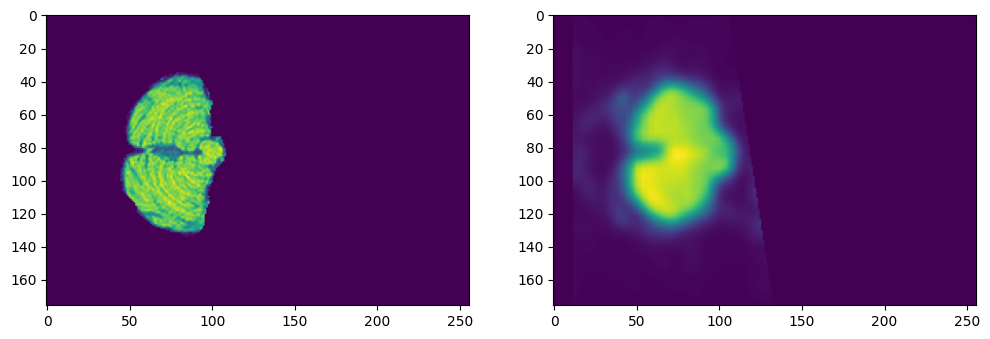

In [12]:
# Registration from FMRI to T1-weighted image

ref = t1_brain_nii

src = avgFmriTemporalVolume(fmri_smoothed)
src = image.new_img_like(fmri_img,src)
aligned_6dof = flirt(src, ref,  dof = 6, cost = 'corratio', interp = 'trilinear', out=LOAD, omat='mat_6dof.mat')['out']

fig, axs = plt.subplots(1,2,figsize=(12,8))
axs[0].imshow(t1_brain[:,:,105])
axs[1].imshow(aligned_6dof.get_fdata()[:,:,105])
plt.show()

(91, 109, 91)


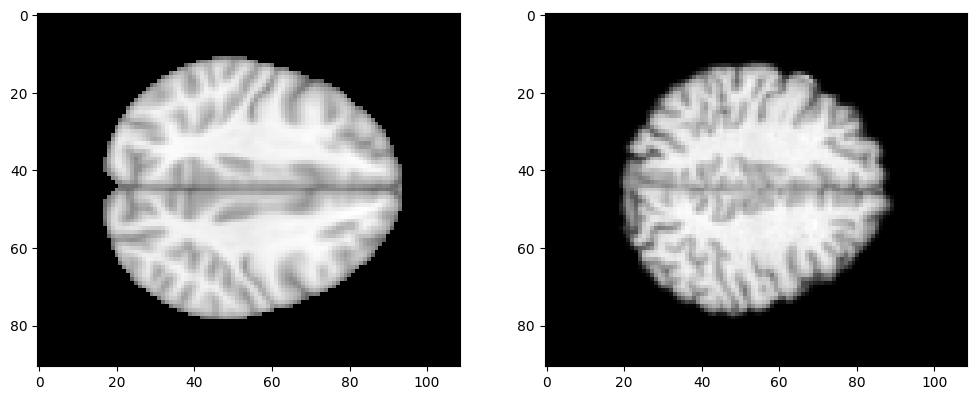

In [16]:
# T1 to MNI registration

print(mni_img.shape)
ref = mni_img

src = t1_brain_nii

aligned_6dof_t1_to_mni = flirt(src, ref,  dof = 6, cost = 'corratio', interp = 'trilinear', out=LOAD, omat='mat_6dof_t1_to_mni.mat')['out']
fig, axs = plt.subplots(1,2,figsize=(12,8))
axs[0].imshow(mni_data[:,:,55], cmap='gray')
axs[1].imshow(aligned_6dof_t1_to_mni.get_fdata()[:,:,55],cmap='gray')
plt.show()

In [18]:
fmri_to_t1_mat = np.loadtxt('mat_6dof.mat')
t1_to_mni_mat = np.loadtxt('mat_6dof_t1_to_mni.mat')

print(fmri_to_t1_mat.shape)
print(t1_to_mni_mat.shape)

(4, 4)
(4, 4)


In [21]:
final_mat = np.matmul(t1_to_mni_mat,fmri_to_t1_mat)
print(final_mat.shape)

np.savetxt("mat_fmri_to_mni.mat", final_mat)

(4, 4)


In [25]:
applyxfm4D(
    src=fmri_smoothed_nii,
    ref=mni_img,
    out="fmri_in_MNI_4D.nii.gz",
    mat="mat_fmri_to_mni.mat",
    singlematrix=True,
)

{}